# Live Visualization — شاهدي الـ Quantum Policy وهي بتلعب

الـ notebook ده بيشغّل episodes من CartPole قدامك ويرسم:
1. **العربية والعصاية** بتتحركوا (matplotlib inline)
2. **الـ Action Probabilities** بتتغير في كل خطوة
3. **الـ Reward** بيتراكم

**ملاحظة:** ده بيشتغل بالتوازي مع `run_all.py` لو شغّال. ممكن يبقى أبطأ شوية بس مفيش conflict.

## الخطوة 1: استيراد المكتبات

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import clear_output, display
import time

from src.quantum_policy import make_policy, action_probs, init_params

print('✅ Imports loaded')

✅ Imports loaded


## الخطوة 2: بناء الـ Quantum Policy

- `make_policy(0.0)` = circuit بدون noise
- `init_params(42)` = الـ 16 زرار بقيم عشوائية (الـ policy لسه ما اتعلمتش)

In [2]:
circuit = make_policy(noise_prob=0.0)

# اختاري المسار:
USE_TRAINED = False  # غيريها لـ True بعد ما run_all.py يخلص

if USE_TRAINED and os.path.exists('../results/trained_params.npy'):
    params = np.load('../results/trained_params.npy')
    print('✅ تم تحميل params مدربة')
else:
    params = init_params(seed=42)
    print('⚠️ بنستخدم params عشوائية (مش مدربة)')

print(f'Shape: {params.shape} — يعني {params.size} زرار')

⚠️ بنستخدم params عشوائية (مش مدربة)
Shape: (2, 4, 2) — يعني 16 زرار


## الخطوة 3: دالة الرسم — العربية والعصاية

هنرسم العربية بأنفسنا بـ matplotlib (مش محتاجين نافذة Gym):

In [3]:
def draw_cartpole(ax, state, step, total_reward, probs, action):
    """رسم العربية والعصاية حسب الـ state."""
    cart_x, cart_v, pole_angle, pole_v = state
    
    ax.clear()
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-0.5, 2)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    
    # الأرضية
    ax.axhline(0, color='gray', linewidth=2)
    
    # العربية
    cart_width = 0.5
    cart_height = 0.3
    cart = Rectangle((cart_x - cart_width/2, 0), cart_width, cart_height,
                     color='steelblue', ec='black')
    ax.add_patch(cart)
    
    # العصاية
    pole_length = 1.0
    pole_x_top = cart_x + pole_length * np.sin(pole_angle)
    pole_y_top = cart_height + pole_length * np.cos(pole_angle)
    ax.plot([cart_x, pole_x_top], [cart_height, pole_y_top],
            color='darkorange', linewidth=6)
    ax.plot(pole_x_top, pole_y_top, 'o', color='red', markersize=10)
    
    # المعلومات
    action_name = 'يمين →' if action == 0 else '← شمال'
    ax.set_title(f'Step {step} | Reward: {total_reward:.0f}\n'
                 f'P(right)={probs[0]:.3f}  P(left)={probs[1]:.3f}  →  {action_name}',
                 fontsize=11)
    ax.set_xlabel('Cart position')

print('✅ Function ready')

✅ Function ready


## الخطوة 4: شغّلي Episode واحد مع رسم Live

هتشوفي العربية بتتحرك خطوة خطوة، والـ probabilities + الـ reward بيتغيروا.

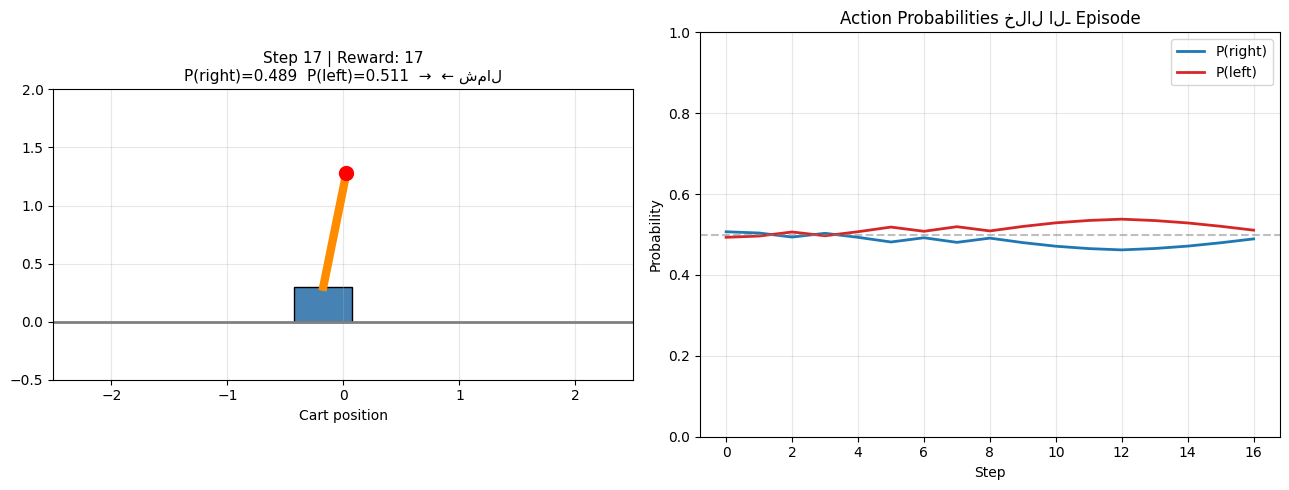


✅ الـ Episode انتهى بعد 17 خطوة، total reward = 17


In [7]:
env = gym.make('CartPole-v1')
state, _ = env.reset(seed=0)

total_reward = 0
step_history = []
prob_history = []

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

done = False
step = 0
while not done and step < 200:
    # 1. الـ policy تحسب الاحتمالات
    probs = action_probs(circuit, state, params)
    
    # 2. اختار action
    action = int(np.random.choice(2, p=probs))
    
    # 3. الـ environment ينفذ
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    total_reward += reward
    step += 1
    
    step_history.append(total_reward)
    prob_history.append(probs)
    
    # ارسمي كل step
    draw_cartpole(axes[0], state, step, total_reward, probs, action)
    
    # رسمة الاحتمالات
    axes[1].clear()
    ph = np.array(prob_history)
    axes[1].plot(ph[:, 0], label='P(right)', color='tab:blue', linewidth=2)
    axes[1].plot(ph[:, 1], label='P(left)', color='tab:red', linewidth=2)
    axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Probability')
    axes[1].set_ylim(0, 1)
    axes[1].set_title('Action Probabilities خلال الـ Episode')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    clear_output(wait=True)
    display(fig)
    
    state = next_state
    time.sleep(0.05)  # تأخير عشان نشوف الحركة

plt.close()
env.close()
print(f'\n✅ الـ Episode انتهى بعد {step} خطوة، total reward = {total_reward:.0f}')

## الخطوة 5: شغّلي 5 episodes ورّيكي الـ rewards

ده هيوريكي إن الـ rewards مش ثابتة — بتختلف من episode للتاني عشان الـ policy stochastic (عشوائية).

**لو الـ policy مدربة كويس:** الأرقام هتبقى كبيرة ومتقاربة.
**لو الـ policy عشوائية:** الأرقام هتبقى صغيرة (10-30) ومتفاوتة.

Episode 1: reward = 22
Episode 2: reward = 14
Episode 3: reward = 30
Episode 4: reward = 11
Episode 5: reward = 20


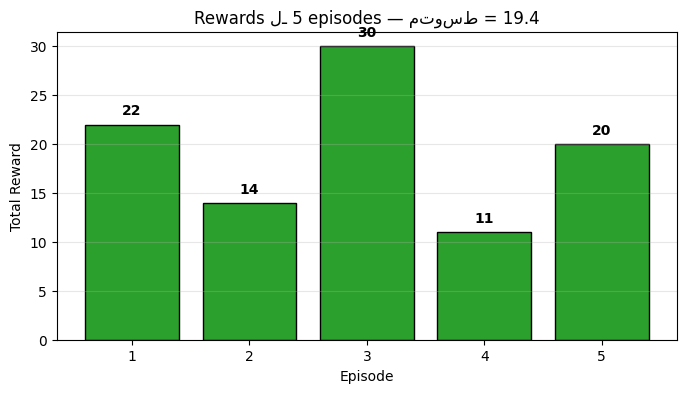

In [5]:
env = gym.make('CartPole-v1')

all_rewards = []
for ep in range(5):
    state, _ = env.reset(seed=ep)
    total = 0
    done = False
    while not done:
        probs = action_probs(circuit, state, params)
        action = int(np.random.choice(2, p=probs))
        state, r, term, trunc, _ = env.step(action)
        total += r
        done = term or trunc
    all_rewards.append(total)
    print(f'Episode {ep+1}: reward = {total:.0f}')

env.close()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), all_rewards, color='tab:green', edgecolor='black')
for i, r in enumerate(all_rewards):
    ax.text(i+1, r+1, f'{r:.0f}', ha='center', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title(f'Rewards لـ 5 episodes — متوسط = {np.mean(all_rewards):.1f}')
ax.grid(alpha=0.3, axis='y')
plt.show()

## 🔍 إيه اللي تلاحظيه؟

**قبل التدريب (`USE_TRAINED = False`):**
- الـ probabilities قريبة من 0.5 (الـ policy بترمي عملة)
- العصاية بتقع بسرعة (10-30 step)
- الـ rewards صغيرة ومتفاوتة

**بعد التدريب (`USE_TRAINED = True`):**
- الـ probabilities بتتغير حسب الـ state (مش 0.5 ثابتة)
- العصاية بتفضل واقفة لفترة أطول
- الـ rewards كبيرة (100-500)

### السؤال للمقابلة 🎤

> **د. سايكس:** *"ليه الاحتمالات قريبة من 0.5 قبل التدريب؟"*
> 
> **رد:** *"الـ params مهيّأة بقيم صغيرة جداً (`scale=0.1`) حوالين الصفر. لما الـ RY/RZ rotations بزوايا صغيرة بتتطبق على qubit في |0⟩، الـ output state بيفضل قريب من |0⟩. فالـ Pauli-Z expectation value قريب من +1 للاتنين qubits، والـ softmax عليهم بيدي 0.5/0.5. ده 'NISQ-friendly init' عشان نتجنب barren plateaus."*

In [8]:
import pennylane as qml
import numpy as np

# نفس الـ circuit بتاع المشروع
dev = qml.device("default.qubit", wires=4)

@qml.qnode(dev)
def my_circuit(state, params):
    # angle encoding
    for i in range(4):
        qml.RY(np.arctan(state[i]), wires=i)
    
    # layer 1
    for q in range(4):
        qml.RY(params[0, q, 0], wires=q)
        qml.RZ(params[0, q, 1], wires=q)
    for q in range(4):
        qml.CNOT(wires=[q, (q + 1) % 4])
    
    return [qml.expval(qml.PauliZ(i)) for i in range(2)]


# state عشوائي
state = np.array([0.1, 0.0, 0.2, 0.0])
params = np.random.uniform(-0.5, 0.5, size=(2, 4, 2))

# اطبعي الـ circuit
print(qml.draw(my_circuit)(state, params))

0: ──RY(0.10)──RY(-0.44)──RZ(0.30)──╭●───────╭X─┤  <Z>
1: ──RY(0.00)──RY(0.48)───RZ(-0.28)─╰X─╭●────│──┤  <Z>
2: ──RY(0.20)──RY(0.32)───RZ(0.18)─────╰X─╭●─│──┤     
3: ──RY(0.00)──RY(-0.42)──RZ(0.16)────────╰X─╰●─┤     


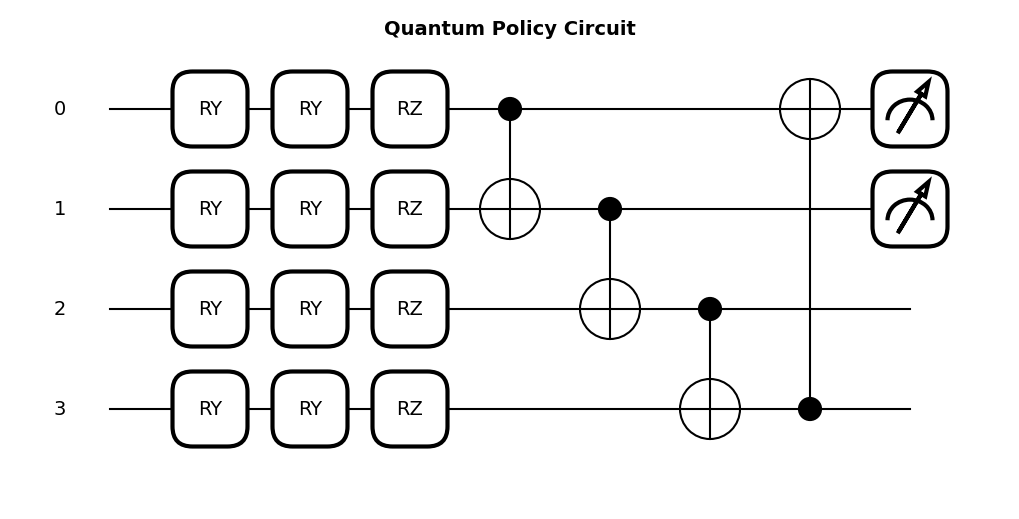

In [9]:
import matplotlib.pyplot as plt

fig, ax = qml.draw_mpl(my_circuit)(state, params)
fig.suptitle("Quantum Policy Circuit", fontsize=14, fontweight='bold')
plt.show()